# 02 · How far do counts spread, and how are sequencing depths matched?

The dispersion $\alpha$ sets how far counts spread around their mean, and a size factor per sample scales the expected count to that sample's sequencing depth. This notebook reproduces the numbers in [notes/02_negative_binomial.md](notes/02_negative_binomial.md) (Korean), which explains each step. The `stopifnot()` lines check them against the note.

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  library(DESeq2); library(ggplot2); requireNamespace("limma", quietly = TRUE)
}))
options(digits = 6, width = 100, repr.plot.width = 7, repr.plot.height = 4.5, repr.plot.res = 110,
        jupyter.plot_mimetypes = "image/png")
near <- function(x, expected, digits) all(abs(unname(x) - expected) <= 0.5 * 10^-digits + 1e-9)  # x rounds to expected
theme_set(theme_minimal(base_size = 12) +
          theme(plot.background = element_rect(fill = "white", colour = NA), panel.grid.minor = element_blank()))

## 1. What the dispersion measures

DESeq2 writes the variance of a count as $\mathrm{Var}(K_{ij}) = \mu_{ij} + \alpha_i\mu_{ij}^2$. The first term is what Poisson already expects, the second is the extra spread between biological replicates. With gene A's final dispersion (0.053147, from note 03) and its control mean:

In [2]:
ctrl <- c(100, 130, 90); m <- mean(ctrl); a <- 0.053147
cat(sprintf("mean %.3f | sample variance of the three counts %.1f\n", m, var(ctrl)))
cat(sprintf("Poisson:              variance %6.1f  (SD %.1f)\n", m, sqrt(m)))
cat(sprintf("NB, alpha = 0.053147: variance %6.1f  (SD %.1f)\n", m + a * m^2, sqrt(m + a * m^2)))
stopifnot(near(m + a * m^2, 711.361, 3))

mean 106.667 | sample variance of the three counts 433.3


Poisson:              variance  106.7  (SD 10.3)


NB, alpha = 0.053147: variance  711.4  (SD 26.7)


The same $\alpha$ gives very different variances at different means, so the variance itself is not a useful summary. The squared coefficient of variation, $CV^2 = 1/\mu + \alpha$, separates the Poisson share ($1/\mu$) from the extra spread ($\alpha$). Rows 1–4 are the table on p.6 of the study text.

In [3]:
tab <- data.frame(mu = c(100, 100, 100, 1000, 30, 30, 50), alpha = c(0, 0.01, 0.1, 0.1, 0.05, 0.2, 0.2))
tab$variance <- tab$mu + tab$alpha * tab$mu^2
tab$CV2      <- 1 / tab$mu + tab$alpha
tab$poisson_share_of_CV2 <- (1 / tab$mu) / tab$CV2
print(tab)
stopifnot(tab$variance[3:4] == c(1100, 101000))

    mu alpha variance       CV2 poisson_share_of_CV2
1  100  0.00      100 0.0100000           1.00000000
2  100  0.01      200 0.0200000           0.50000000
3  100  0.10     1100 0.1100000           0.09090909
4 1000  0.10   101000 0.1010000           0.00990099
5   30  0.05       75 0.0833333           0.40000000
6   30  0.20      210 0.2333333           0.14285714
7   50  0.20      550 0.2200000           0.09090909


Rows 3 and 4 have the same $\alpha$ and variances 92 times apart, yet almost the same $CV^2$. Low counts do not have a large absolute variance. They have a large relative one, mostly from the Poisson term.

## 2. The shape of the negative binomial

$$P(K=k)=\frac{\Gamma(k+r)}{\Gamma(r)\,k!}\Big(\frac{r}{r+\mu}\Big)^{r}\Big(\frac{\mu}{r+\mu}\Big)^{k},\qquad r=\frac{1}{\alpha}$$

In R this is `dnbinom(k, size = 1/alpha, mu = mu)`. Passing `size = alpha` gives a different distribution.

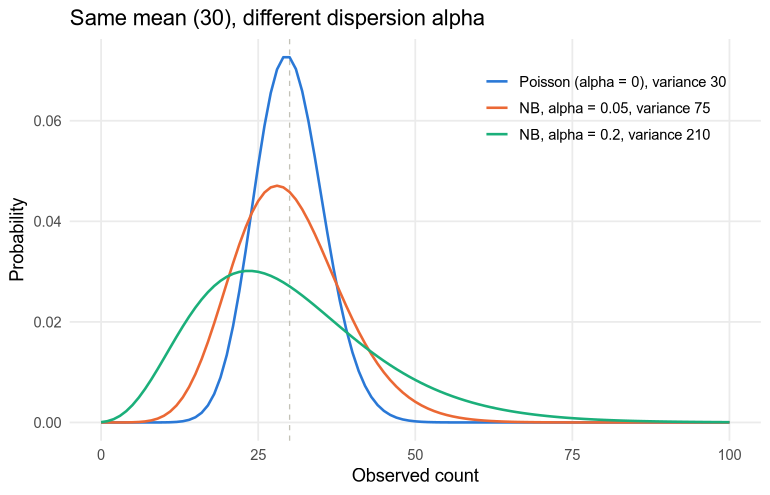

In [4]:
k <- 0:100
lv <- c("Poisson (alpha = 0), variance 30", "NB, alpha = 0.05, variance 75", "NB, alpha = 0.2, variance 210")
d <- rbind(data.frame(k, p = dpois(k, 30), model = lv[1]),
           data.frame(k, p = dnbinom(k, size = 1 / 0.05, mu = 30), model = lv[2]),
           data.frame(k, p = dnbinom(k, size = 1 / 0.2,  mu = 30), model = lv[3]))
d$model <- factor(d$model, levels = lv)
ggplot(d, aes(k, p, colour = model)) +
  geom_vline(xintercept = 30, colour = "#c3c2b7", linetype = "dashed", linewidth = 0.4) +
  geom_line(linewidth = 0.8) +
  scale_colour_manual(values = c("#2a78d6", "#eb6834", "#1baf7a"), name = NULL) +
  labs(x = "Observed count", y = "Probability", title = "Same mean (30), different dispersion alpha") +
  theme(legend.position = "inside", legend.position.inside = c(0.98, 0.95), legend.justification = c(1, 1))

In [5]:
mu <- 30; alpha <- 0.05; r <- 1 / alpha
nb_formula <- function(k) exp(lgamma(k + r) - lgamma(r) - lgamma(k + 1) + r * log(r / (r + mu)) + k * log(mu / (r + mu)))
gap <- max(abs(nb_formula(0:500) - dnbinom(0:500, size = r, mu = mu)))
kk <- 0:2000; p <- dnbinom(kk, size = r, mu = mu)
cat("max |formula - dnbinom| for k = 0..500:", gap, "\n")
cat("variance from the probabilities:", sum(kk^2 * p) - sum(kk * p)^2, " | mu + alpha * mu^2 =", mu + alpha * mu^2, "\n")
stopifnot(gap < 1e-12, abs(sum(kk^2 * p) - sum(kk * p)^2 - 75) < 1e-6)

ranges <- t(sapply(c(0, 0.05, 0.2), function(a) {
  size <- if (a == 0) Inf else 1 / a                    # size = Inf gives the Poisson
  c(alpha = a, q2.5 = qnbinom(0.025, size = size, mu = 30), q97.5 = qnbinom(0.975, size = size, mu = 30),
    `P(K<=20)` = pnbinom(20, size = size, mu = 30))
}))
print(round(ranges, 4))

max |formula - dnbinom| for k = 0..500: 2.08167e-15 


variance from the probabilities: 75  | mu + alpha * mu^2 = 75 


     alpha q2.5 q97.5 P(K<=20)
[1,]  0.00   20    41   0.0353
[2,]  0.05   15    49   0.1298
[3,]  0.20    8    64   0.2811


At the same mean of 30, the middle 95% widens from [20, 41] to [15, 49] to [8, 64] as $\alpha$ grows.

## 3. One dispersion per gene

A gene gets one $\alpha$, while its expected count can differ between samples. The mean structure (the design) explains group differences, and $\alpha$ only covers the spread left around it. Leave the condition out of the design and the group difference leaks into $\alpha$:

In [6]:
K_A <- c(100, 130, 90, 200, 250, 180)
grp <- factor(rep(c("Ctrl", "Starvation"), each = 3))
nll <- function(log_a, mu) -sum(dnbinom(K_A, size = exp(-log_a), mu = mu, log = TRUE))
mle <- function(mu) exp(optimize(nll, log(c(1e-8, 10)), mu = mu, tol = 1e-12)$minimum)
a_condition <- mle(ave(K_A, grp))            # ~ condition: each sample uses its group mean
a_one       <- mle(rep(mean(K_A), 6))        # ~ 1: all six samples share one mean
cat(sprintf("alpha (MLE)  ~ condition: %.6f   ~ 1: %.5f\n", a_condition, a_one))
stopifnot(near(a_condition, 0.014786, 6), near(a_one, 0.12509, 5))

alpha (MLE)  ~ condition: 0.014786   ~ 1: 0.12509


## 4. Size factors: median-of-ratios

DESeq2 models the expected count as $\mu_{ij} = s_j q_{ij}$, where $s_j$ is the size factor of sample $j$. It estimates $s_j$ as the median over genes of each count's ratio to that gene's geometric mean across samples:

$$g_i=\Big(\prod_{j=1}^{n}K_{ij}\Big)^{1/n},\qquad \hat s_j=\operatorname{median}_i\frac{K_{ij}}{g_i}$$

The three-gene table from p.8 of the study text, where sample 2 was sequenced twice as deep:

In [7]:
K <- matrix(c(100, 200, 50, 100, 200, 400), nrow = 3, byrow = TRUE,
            dimnames = list(c("g1", "g2", "g3"), c("sample1", "sample2")))
g <- exp(rowMeans(log(K)))                  # geometric mean per gene: the reference sample
s_hand <- apply(K / g, 2, median)
print(cbind(K, reference = g, K / g))
cat("by hand:", s_hand, "| estimateSizeFactorsForMatrix:", estimateSizeFactorsForMatrix(K), "\n")
stopifnot(all.equal(s_hand, estimateSizeFactorsForMatrix(K)), all.equal(unname(s_hand[2] / s_hand[1]), 2))

# One gene that is 20 times higher in sample 2 moves the total-count ratio, not the median
K4 <- rbind(K, g4 = c(1000, 20000))
sf4 <- estimateSizeFactorsForMatrix(K4); tc4 <- colSums(K4) / mean(colSums(K4))
cat(sprintf("sample2/sample1 ratio: median-of-ratios %.4f | total counts %.4f\n", sf4[2] / sf4[1], tc4[2] / tc4[1]))
stopifnot(all.equal(unname(sf4[2] / sf4[1]), 2), near(tc4[2] / tc4[1], 15.3333, 4))

   sample1 sample2 reference  sample1 sample2
g1     100     200  141.4214 0.707107 1.41421
g2      50     100   70.7107 0.707107 1.41421
g3     200     400  282.8427 0.707107 1.41421


by hand: 0.707107 1.41421 | estimateSizeFactorsForMatrix: 0.707107 1.41421 


sample2/sample1 ratio: median-of-ratios 2.0000 | total counts 15.3333


The same calculation for one sample of a simulated data set with 2,000 genes. Genes with a zero in any sample drop out, because their geometric mean is 0.

genes used: 1469 of 2000 | median ratio: 1.94983 | sizeFactors(): 1.94983 


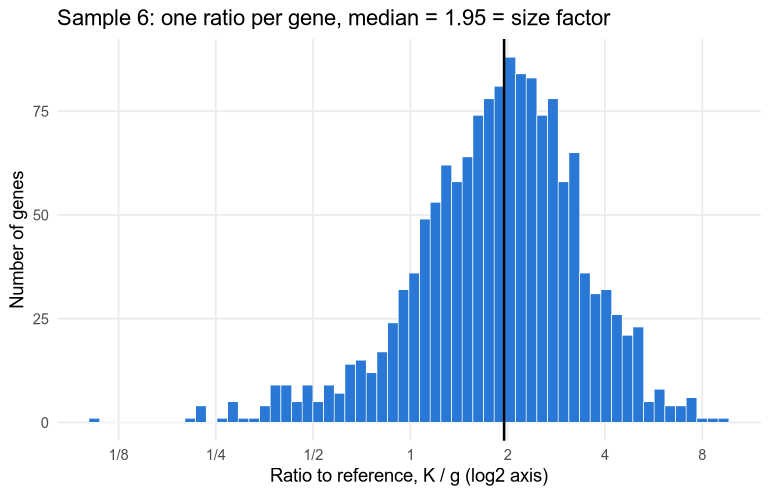

In [8]:
set.seed(42)
dsim <- makeExampleDESeqDataSet(n = 2000, m = 6, sizeFactors = c(0.5, 1, 1.5, 0.8, 1.2, 2))
cnt <- counts(dsim)
use <- rowSums(cnt == 0) == 0
rat <- cnt[use, "sample6"] / exp(rowMeans(log(cnt[use, ])))
sf6 <- sizeFactors(estimateSizeFactors(dsim))[["sample6"]]
cat("genes used:", sum(use), "of", nrow(cnt), "| median ratio:", median(rat), "| sizeFactors():", sf6, "\n")
stopifnot(sum(use) == 1469, all.equal(median(rat), sf6))
ggplot(data.frame(rat), aes(rat)) +
  geom_histogram(bins = 60, fill = "#2a78d6", colour = "white", linewidth = 0.2) +
  geom_vline(xintercept = median(rat), linewidth = 0.8) +
  scale_x_continuous(trans = "log2", breaks = 2^(-3:3), labels = c("1/8", "1/4", "1/2", "1", "2", "4", "8")) +
  labs(x = "Ratio to reference, K / g (log2 axis)", y = "Number of genes",
       title = sprintf("Sample 6: one ratio per gene, median = %.2f = size factor", median(rat)))

## 5. Where the size factor enters the model

The size factor is an offset in the GLM: $\log\mu_{ij}=\log s_j + x_j^T b_i$, with the coefficient of $\log s_j$ fixed at 1. For gene A with design `~ condition`:

In [9]:
X <- cbind(Intercept = 1, Starvation = rep(0:1, each = 3))
b <- c(log(320 / 3), log(210 / (320 / 3)))            # natural-log coefficients
print(cbind(X, mu = drop(exp(X %*% b))))
cat("log2 coefficients b / log(2):", b / log(2), "\n")
stopifnot(near(b[2] / log(2), 0.97728, 6))

     Intercept Starvation      mu
[1,]         1          0 106.667
[2,]         1          0 106.667
[3,]         1          0 106.667
[4,]         1          1 210.000
[5,]         1          1 210.000
[6,]         1          1 210.000


log2 coefficients b / log(2): 6.73697 0.97728 


Because the offset's coefficient is fixed, doubling every size factor (with the dispersions held fixed) has to lower the log2 intercept by exactly 1 and leave the condition effect alone:

In [10]:
set.seed(7)
d1 <- makeExampleDESeqDataSet(n = 300, m = 6, betaSD = 1, sizeFactors = c(0.5, 1, 1.5, 0.8, 1.2, 2))
d1 <- DESeq(d1, quiet = TRUE)
d2 <- d1; sizeFactors(d2) <- 2 * sizeFactors(d1)     # dispersions(d2) stay those of d1
d2 <- nbinomWaldTest(d2, quiet = TRUE)
shift <- range(coef(d2)[, 1] - coef(d1)[, 1], na.rm = TRUE)
moved <- max(abs(coef(d2)[, 2] - coef(d1)[, 2]), na.rm = TRUE)
cat("intercept shift:", shift, "| largest change in the condition coefficient:", moved, "\n")
stopifnot(abs(shift + 1) < 1e-4, moved < 1e-4)

intercept shift: -1.00004 -0.999976 | largest change in the condition coefficient: 3.67796e-05 


## 6. What normalized counts do not remove

`counts(dds, normalized = TRUE)` only divides by the size factors. Putting `pair` in the design does not take donor differences out of the normalized counts. Below, genes 1–200 get a donor effect of 1×, 2× and 4× in donors p1–p3, and the true condition effect is 0 everywhere.

In [11]:
set.seed(3)
dp <- makeExampleDESeqDataSet(n = 1000, m = 6, betaSD = 0)
dp$pair <- factor(rep(c("p1", "p2", "p3"), each = 2)); dp$condition <- factor(rep(c("A", "B"), 3))
cnt <- counts(dp); effect <- c(p1 = 1, p2 = 2, p3 = 4)[as.character(dp$pair)]
cnt[1:200, ] <- round(t(t(cnt[1:200, ]) * effect)); storage.mode(cnt) <- "integer"; counts(dp) <- cnt
design(dp) <- ~ pair + condition
dp <- DESeq(dp, quiet = TRUE)
nc <- counts(dp, normalized = TRUE)
pair_means <- sapply(split(seq_len(6), dp$pair), function(j) rowMeans(nc[, j, drop = FALSE]))
geo <- round(exp(colMeans(log(pair_means[1:200, ] + 0.5))), 2)
cat("normalized counts, genes 1-200, geometric mean per donor:", geo, "\n")
pair_coef <- apply(coef(dp)[1:200, 2:3], 2, median, na.rm = TRUE)    # all-zero genes have NA coefficients
cat("GLM pair coefficients (log2), median over genes 1-200:", round(pair_coef, 3), "\n")
lb <- limma::removeBatchEffect(log2(nc + 1), batch = dp$pair, design = model.matrix(~ condition, colData(dp)))
after <- round(2^sapply(split(seq_len(6), dp$pair), function(j) mean(lb[1:200, j])), 2)
cat("after limma::removeBatchEffect (for plots only):", after, "\n")
stopifnot(all(diff(geo) > 0), near(pair_coef, c(0.67, 1.652), 3), length(unique(after)) == 1)

normalized counts, genes 1-200, geometric mean per donor: 16.75 27.03 47.75 


GLM pair coefficients (log2), median over genes 1-200: 0.67 1.652 


after limma::removeBatchEffect (for plots only): 26.2 26.2 26.2 


The donor effect stays in the normalized counts. The GLM's pair coefficients absorb it (the medians fall short of the true log2 values 1 and 2 because part of the effect moved into the size factors), and only a separate step such as `removeBatchEffect()` removes it for visualization. DESeq2 itself always takes raw counts and the design.

## Takeaways

- $\alpha$ is the extra spread on top of Poisson, not the variance. The same $\alpha$ gives variances 92 times apart at means of 100 and 1,000.
- `dnbinom(size = 1/alpha, mu = mu)` is DESeq2's negative binomial.
- A gene has one $\alpha$; group differences belong in the design. Leaving the condition out raises gene A's $\alpha$ from 0.0148 to 0.125.
- Size factors are medians of ratios to a per-gene geometric mean, so a few extreme genes barely move them.
- The size factor enters the GLM as an offset with its coefficient fixed at 1, and normalized counts are not batch- or donor-corrected.

Next: [03_dispersion_estimation.R](03_dispersion_estimation.R).